In [1]:
"""
    Importeer libraries
    """
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from math import sqrt, ceil
from scipy.stats import linregress    
import libraries as lib
import math 
import plotly.express as px
import plotly.graph_objects as go

    

In [2]:
"""
    Laadt motordriver-data in, selecteert een subset van rijen, corrigeert GPS-coördinaten
    en voegt snelheden in m/s toe.

    Parameters:
    directory (str): Pad naar de directory met het databestand.
    file_motordriver (str): Naam van het motordriver-databestand.
    start_row (int): Startindex van de te selecteren rijen (inclusief).
    end_row (int): Eindindex van de te selecteren rijen (inclusief).

    Returns:
    pd.DataFrame: Geprocessed DataFrame met geselecteerde rijen, gecorrigeerde GPS-coördinaten
                  en snelheden in m/s.
    """
import libraries as lib

directory2 = "/Users\qvled\OneDrive - HvA\Logfiles\H2A/2022/20221027T153630 46m11s 2.264km P2 Arena/"
directory = "/Users\qvled\OneDrive - HvA\Logfiles\H2A/2023/Nogaro/20230525_h2a_poging1/0002/"
# file_motordriver = "3.csv"
file_motordriver = "3_DCMD_H2A_03_04.csv"
# start_row = 223257
# end_row = 479444

start_row = 0
end_row = -1

filtered_motordriver = lib.verwerk_motordriver_data(directory2, file_motordriver, start_row, end_row)

# Voeg de rij-index expliciet toe als kolom
filtered_motordriver = filtered_motordriver.reset_index()

filtered_motordriver



,index,Datalogger port,"Dataloggertijd, in s",Format header (>03|04),Tijd sinds laatste herstart motordriver (s),Spanning over de motor (V),Stroom door de motor (A),Vermogen geleverd aan de motor (W),Energie geleverd aan de motor sinds reset (J),Spanning aan de ingang van motordriver (V),...,"Toestand cruise control2-knop (aan=1, uit=0)",Tijdstip laatste verandering cruise control2-knop,"GPS longitude, in graden","GPS latitude, in graden",GPS direction,"GPS speed, in km/h","GPS time, in seconden sinds het begin van de huidige GPS-week",Checksum,"Wielsnelheid, in m/s","GPS speed, in m/s"
0,0,3,99.1790,03|04,0.0060,2.045,0.010,0.2,0,2.322,...,0,0.000,NaN,NaN,NaN,NaN,NaN,NaN,1.085278,NaN
1,1,3,99.1846,03|04,0.0116,3.702,0.017,0.3,0,4.202,...,0,0.000,NaN,NaN,NaN,NaN,NaN,NaN,0.601389,NaN
2,2,3,99.1902,03|04,0.0172,5.197,0.025,0.5,0,5.896,...,0,0.000,4.933295,52.313858,NaN,NaN,NaN,NaN,0.429722,NaN
3,3,3,99.1967,03|04,0.0236,6.727,0.031,0.6,0,7.630,...,0,0.000,4.933295,52.313858,175.0,2.2,133659.0,NaN,0.333056,0.611111
4,4,3,99.2040,03|04,0.0310,8.288,0.038,0.7,0,9.396,...,0,0.000,4.933295,52.313858,175.0,2.2,133659.0,NaN,0.000000,0.611111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118530,118530,3,2271.1957,03|04,945.9646,0.044,0.230,0.0,48453,8.323,...,0,925.735,4.933190,52.313925,164.2,0.0,141309.0,NaN,0.000000,0.000000
118531,118531,3,2271.2039,03|04,945.9728,0.044,0.236,0.0,48453,8.018,...,0,925.735,4.933190,52.313925,164.2,0.0,141309.0,NaN,0.000000,0.000000
118532,118532,3,2271.2121,03|04,945.9810,0.044,0.245,0.0,48453,7.704,...,0,925.735,4.933190,52.313925,164.2,0.0,141309.0,NaN,0.000000,0.000000
118533,118533,3,2271.2202,03|04,945.9892,0.044,0.253,0.0,48453,7.379,...,0,925.735,4.933190,52.313925,164.2,0.0,141309.0,NaN,0.000000,0.000000


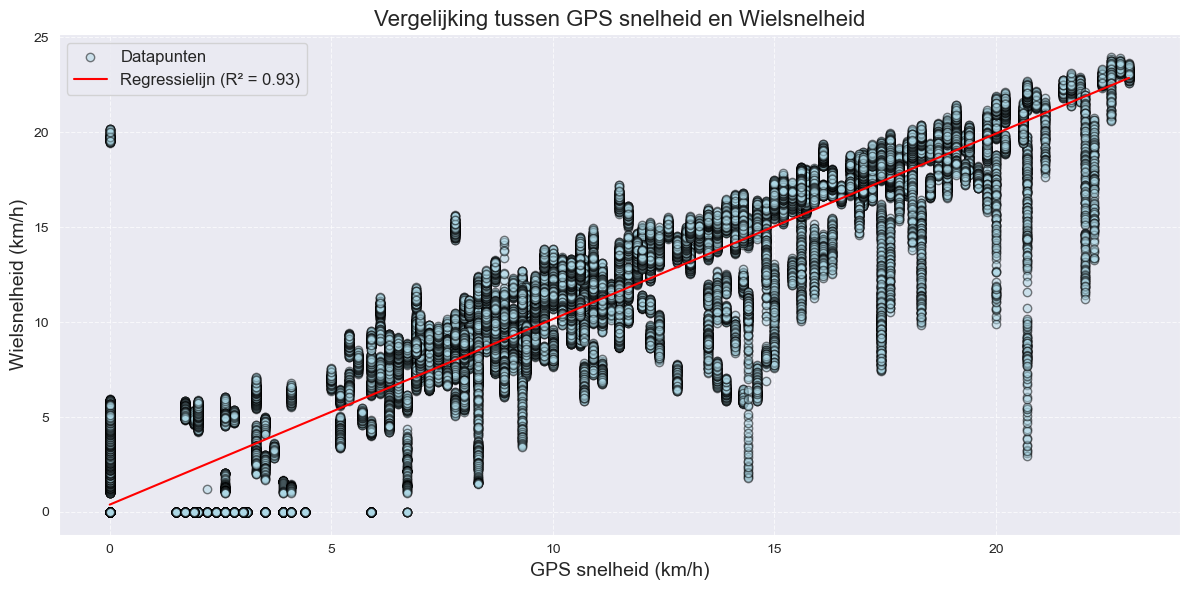

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

filtered_data = filtered_motordriver.dropna(subset=['GPS speed, in km/h', 'Wielsnelheid, in km/h'])

# Regressieanalyse
slope, intercept, r_value, p_value, std_err = linregress(
    filtered_data['GPS speed, in km/h'],
    filtered_data['Wielsnelheid, in km/h']
)


x_vals = np.linspace(min(filtered_data['GPS speed, in km/h']), max(filtered_data['GPS speed, in km/h']), 500)
y_vals = slope * x_vals + intercept

plt.figure(figsize=(12, 6))
plt.scatter(filtered_data['GPS speed, in km/h'], filtered_data['Wielsnelheid, in km/h'], alpha=0.5, label='Datapunten', color='lightblue', edgecolors='k')
plt.plot(x_vals, y_vals, color='red', label=f'Regressielijn (R² = {r_value**2:.2f})')
plt.title('Vergelijking tussen GPS snelheid en Wielsnelheid', fontsize=16)
plt.xlabel('GPS snelheid (km/h)', fontsize=14)
plt.ylabel('Wielsnelheid (km/h)', fontsize=14)
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()



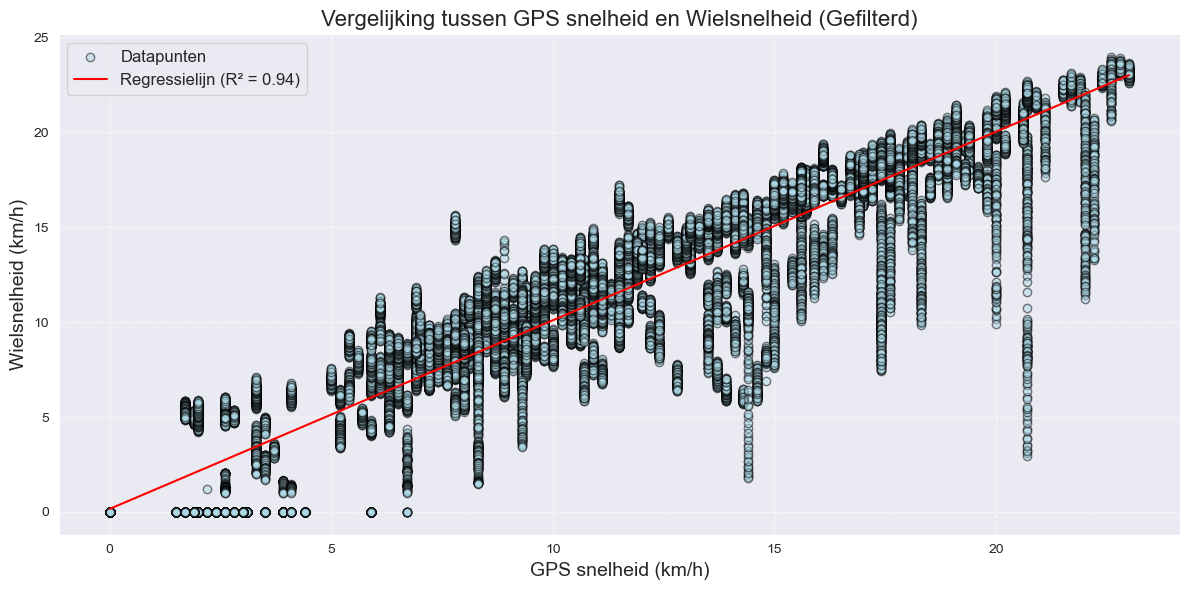

In [4]:
# Filter out rows where GPS speed is zero but wheel speed is not zero
filtered_data = filtered_data[~((filtered_data['GPS speed, in km/h'] == 0) & (filtered_data['Wielsnelheid, in km/h'] != 0))]

# Recalculate regression with the cleaned data
slope, intercept, r_value, p_value, std_err = linregress(
    filtered_data['GPS speed, in km/h'],
    filtered_data['Wielsnelheid, in km/h']
)

# Recalculate x and y values for the regression line
x_vals = np.linspace(min(filtered_data['GPS speed, in km/h']), max(filtered_data['GPS speed, in km/h']), 500)
y_vals = slope * x_vals + intercept

# Plot the cleaned data and the regression line
plt.figure(figsize=(12, 6))
plt.scatter(filtered_data['GPS speed, in km/h'], filtered_data['Wielsnelheid, in km/h'], alpha=0.5, label='Datapunten', color='lightblue', edgecolors='k')
plt.plot(x_vals, y_vals, color='red', label=f'Regressielijn (R² = {r_value**2:.2f})')
plt.title('Vergelijking tussen GPS snelheid en Wielsnelheid (Gefilterd)', fontsize=16)
plt.xlabel('GPS snelheid (km/h)', fontsize=14)
plt.ylabel('Wielsnelheid (km/h)', fontsize=14)
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


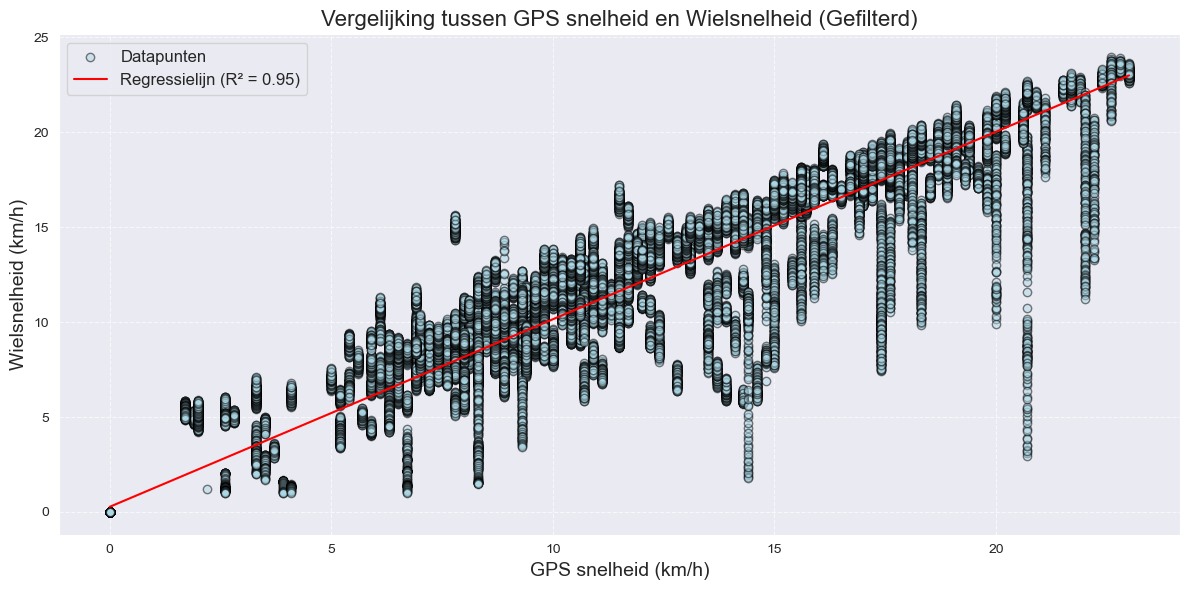

In [5]:
# Filter out rows where GPS speed is zero but wheel speed is not zero
filtered_data = filtered_data[~((filtered_data['Wielsnelheid, in km/h'] == 0) & (filtered_data['GPS speed, in km/h'] != 0))]

# Recalculate regression with the cleaned data
slope, intercept, r_value, p_value, std_err = linregress(
    filtered_data['GPS speed, in km/h'],
    filtered_data['Wielsnelheid, in km/h']
)

# Recalculate x and y values for the regression line
x_vals = np.linspace(min(filtered_data['GPS speed, in km/h']), max(filtered_data['GPS speed, in km/h']), 500)
y_vals = slope * x_vals + intercept

# Plot the cleaned data and the regression line
plt.figure(figsize=(12, 6))
plt.scatter(filtered_data['GPS speed, in km/h'], filtered_data['Wielsnelheid, in km/h'], alpha=0.5, label='Datapunten', color='lightblue', edgecolors='k')
plt.plot(x_vals, y_vals, color='red', label=f'Regressielijn (R² = {r_value**2:.2f})')
plt.title('Vergelijking tussen GPS snelheid en Wielsnelheid (Gefilterd)', fontsize=16)
plt.xlabel('GPS snelheid (km/h)', fontsize=14)
plt.ylabel('Wielsnelheid (km/h)', fontsize=14)
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


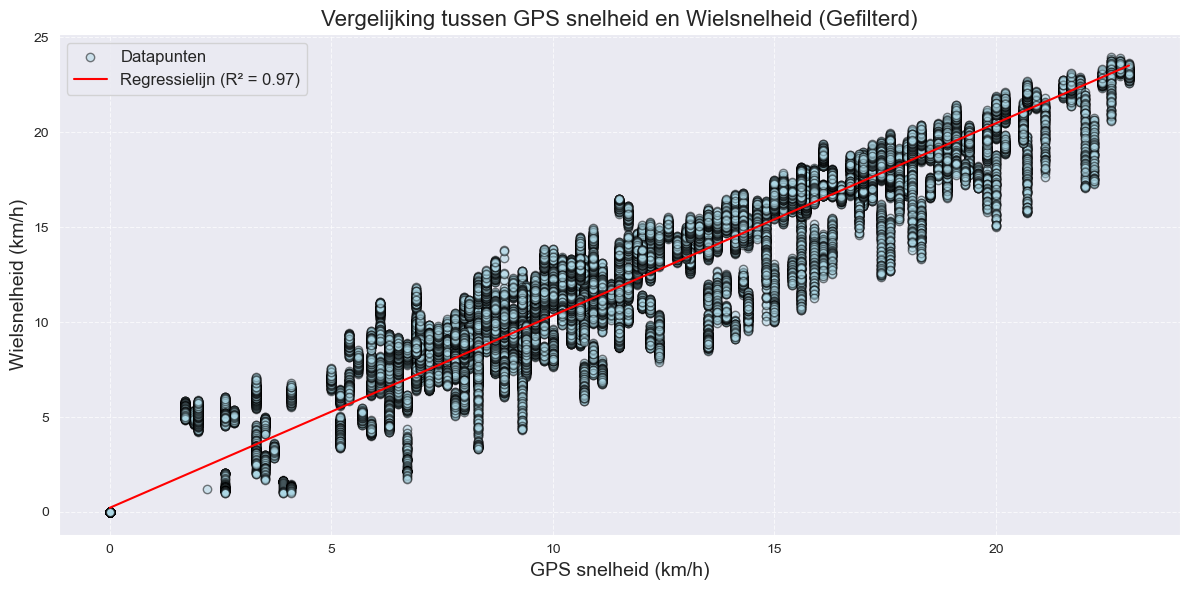

In [6]:
# Verwijder punten waar het verschil tussen GPS en wielsnelheid te groot is
filtered_data = filtered_data[
    abs(filtered_data['GPS speed, in km/h'] - filtered_data['Wielsnelheid, in km/h']) < 5  # Pas de drempel aan
]

# Recalculate regression with the cleaned data
slope, intercept, r_value, p_value, std_err = linregress(
    filtered_data['GPS speed, in km/h'],
    filtered_data['Wielsnelheid, in km/h']
)

# Recalculate x and y values for the regression line
x_vals = np.linspace(min(filtered_data['GPS speed, in km/h']), max(filtered_data['GPS speed, in km/h']), 500)
y_vals = slope * x_vals + intercept

# Plot the cleaned data and the regression line
plt.figure(figsize=(12, 6))
plt.scatter(filtered_data['GPS speed, in km/h'], filtered_data['Wielsnelheid, in km/h'], alpha=0.5, label='Datapunten', color='lightblue', edgecolors='k')
plt.plot(x_vals, y_vals, color='red', label=f'Regressielijn (R² = {r_value**2:.2f})')
plt.title('Vergelijking tussen GPS snelheid en Wielsnelheid (Gefilterd)', fontsize=16)
plt.xlabel('GPS snelheid (km/h)', fontsize=14)
plt.ylabel('Wielsnelheid (km/h)', fontsize=14)
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

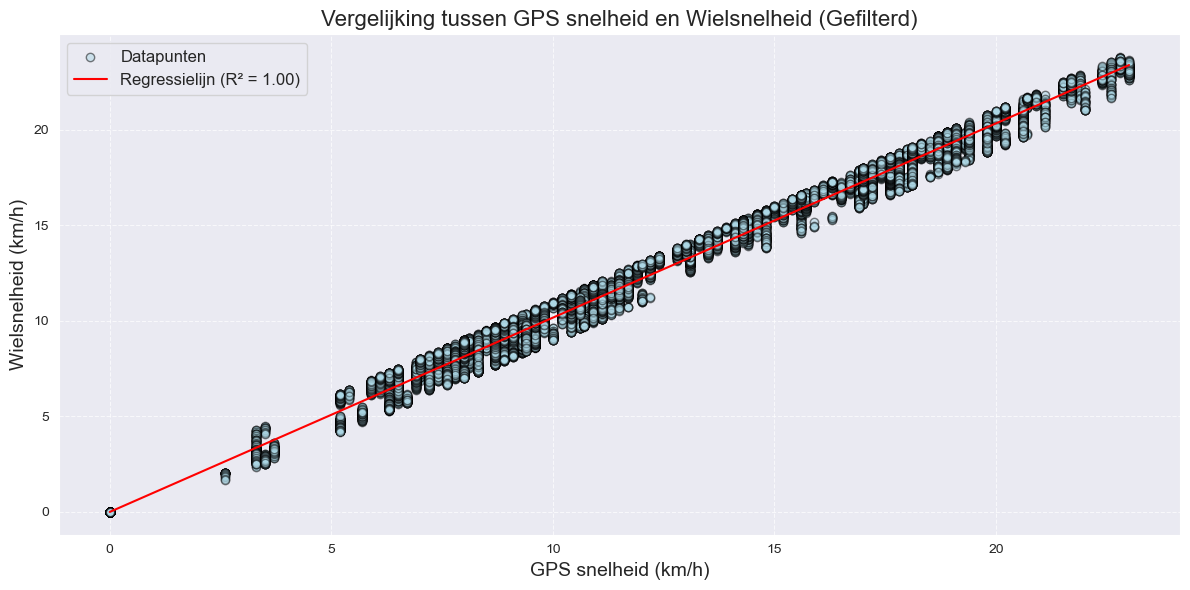

In [8]:
# Verwijder punten waar het verschil tussen GPS en wielsnelheid te groot is
filtered_data = filtered_data[
    abs(filtered_data['GPS speed, in km/h'] - filtered_data['Wielsnelheid, in km/h']) < 1  # Pas de drempel aan
]

# Recalculate regression with the cleaned data
slope, intercept, r_value, p_value, std_err = linregress(
    filtered_data['GPS speed, in km/h'],
    filtered_data['Wielsnelheid, in km/h']
)

# Recalculate x and y values for the regression line
x_vals = np.linspace(min(filtered_data['GPS speed, in km/h']), max(filtered_data['GPS speed, in km/h']), 500)
y_vals = slope * x_vals + intercept

# Plot the cleaned data and the regression line
plt.figure(figsize=(12, 6))
plt.scatter(filtered_data['GPS speed, in km/h'], filtered_data['Wielsnelheid, in km/h'], alpha=0.5, label='Datapunten', color='lightblue', edgecolors='k')
plt.plot(x_vals, y_vals, color='red', label=f'Regressielijn (R² = {r_value**2:.2f})')
plt.title('Vergelijking tussen GPS snelheid en Wielsnelheid (Gefilterd)', fontsize=16)
plt.xlabel('GPS snelheid (km/h)', fontsize=14)
plt.ylabel('Wielsnelheid (km/h)', fontsize=14)
plt.grid(visible=True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()